# 第6回：差分進化（Differential Evolution, DE）

```{note}
:class: dropdown
:open: true
このページは **MyST Markdown** として管理している．対話的に実行する場合は，Jupyter / VS Code / Cursor で本ファイルを開くか，下の Python コードブロックをノートブックへコピーして用いる．
```

本ページでは，実数ベクトル最適化で広く使われる **Differential Evolution（DE）** を扱う．DE は **遺伝的アルゴリズム（GA）などと同じく進化的アルゴリズム（EA）** の流れをくむ手法であり，変異・交叉・選択という語彙で説明できる点を中心に，直感，数式，疑似コード，実装，演習の順で整理する．

---


## 0. このページで学ぶこと

1. DE の基本概念（変異・交叉・選択）と，**GA（進化的アルゴリズム）との対応と相違**．
2. 代表戦略 **DE/rand/1/bin** の数式と処理の対応．
3. 主要パラメータ $F$，$CR$，集団サイズ $NP$ の役割．
4. 2次元テスト関数での挙動可視化．
5. SciPy の `differential_evolution` を使った連続最適化の実践．
6. **演習：DE による SVM の特徴選択**（Wine データセット）．

---

(sec:de-ch1)=


## 1. Differential Evolution（DE）とは

DE は，実数ベクトルの最適化に強いメタヒューリスティクスである．目的関数の勾配が不要であり，ブラックボックス最適化に使いやすい．


### 1.1 位置づけ

- **勾配不要**：$f(\boldsymbol{x})$ が計算できれば適用可能．
- **集団ベース**：複数の候補解を同時に保持し，多点探索する．
- **近似解法**：一般に大域最適性保証はないが，実務で強いことが多い．


### 1.2 GA（進化的アルゴリズム）との対応（直感）

DE は，文献では **進化的アルゴリズム（Evolutionary Algorithm; EA）の一種** と位置づけられることが多い（例：個体＝候補解，評価値＝適応度）．GA と同様に，1 世代あたりの処理を次の 3 段階で説明できる．

| 段階 | DE（本ページの流れ） | 典型 GA とのイメージ差 |
| --- | --- | --- |
| **変異（mutation）** | 3 個体 $\boldsymbol{x}_{r_1},\boldsymbol{x}_{r_2},\boldsymbol{x}_{r_3}$ から差分 $\boldsymbol{x}_{r_2}-\boldsymbol{x}_{r_3}$ をとり，$\boldsymbol{x}_{r_1}+F(\cdots)$ で **変異ベクトル** $\boldsymbol{v}_i$ をつくる | しばしば「小さなランダム摂動」や別の演算子で突然変異を定義する |
| **交叉（crossover）** | ターゲット $\boldsymbol{x}_i$ と $\boldsymbol{v}_i$ を **二項交叉（binomial）** で混ぜ，試行個体 $\boldsymbol{u}_i$ を得る | 多くは **2 親の染色体** を一点／二点／一様交叉などで組み替える |
| **生存選択（selection）** | $\boldsymbol{u}_i$ と $\boldsymbol{x}_i$ を **1 対 1 で比較**し，良い方だけ残す（greedy） | 世代交代，トーナメント，エリート保存など，設計の自由度が大きい |

差分ベクトルで探索方向を決める点は，**複数点の幾何関係に基づく更新**という意味で Nelder–Mead 法の reflection などに連想される説明もある（DE 全体を「Nelder–Mead に EA の発想を重ねた」とみなす見方）．いずれにせよ，**「集団の形状から探索ステップを組み立てる」** という GA の標準的な実数コード化より機械的な手続きになっている点が特徴である．

補足として，**粒子の速度を更新する PSO**（第4回: https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso ）とは設計思想が異なり，本ページでは **EA／GA の語彙との対応** を主軸とする．

---

(sec:de-ch2)=


## 2. DE の更新式（DE/rand/1/bin）

最小化問題
$$
\min_{\boldsymbol{x}\in\mathbb{R}^d} f(\boldsymbol{x})
$$
を考える．集団を $\{\boldsymbol{x}_1,\ldots,\boldsymbol{x}_{NP}\}$ とする．

戦略名 **DE/rand/1/bin** の読み方は文献でもよく使われる略記である．

- **rand**：基準個体 $\boldsymbol{x}_{r_1}$ を，ターゲット $i$ および $r_2,r_3$ と重ならないようにランダムに選ぶ（**best** 系では $\boldsymbol{x}_{r_1}$ を当期最良個体に置き換える）．
- **1**：変異に用いる **差分ベクトルの本数** が 1 本であること（**rand/2** などでは 2 本の差分を組み合わせる）．
- **bin**：各次元を確率 $CR$ で入れ替える **二項（binomial）交叉** であること（**exp** と呼ばれる指数交叉などの別定義もある）．


### 2.1 変異（mutation）

ターゲット個体 $\boldsymbol{x}_i$ に対し，異なる3個体 $r_1,r_2,r_3$ を取り，
$$
\boldsymbol{v}_i = \boldsymbol{x}_{r_1} + F(\boldsymbol{x}_{r_2} - \boldsymbol{x}_{r_3})
$$
をつくる．$F>0$ は差分の **スケール係数（scaling factor）** であり，文献ではしばしば **$F\in(0,2]$ 付近** を想定する説明がある（大きすぎると探索が不安定になりやすい）．実装例では $F\approx 0.5$〜$1.0$ 前後がよく用いられる．


### 2.2 交叉（binomial crossover）

試行個体 $\boldsymbol{u}_i$ を次で作る．
$$
u_{i,j}=\begin{cases}
v_{i,j}, & \text{if } rand_j \le CR \text{ or } j=j_{rand}\\
x_{i,j}, & \text{otherwise}
\end{cases}
$$
$CR\in[0,1]$ は交叉率．$j_{rand}$ は少なくとも1次元を変異ベクトル側から採用するための強制インデックスである．

二項交叉には，次のような **幾何学的直感** もつけられる．$\boldsymbol{v}_i$ とターゲット $\boldsymbol{x}_i$ を，各次元が区間 $[\min(v_{ij},x_{ij}),\max(v_{ij},x_{ij})]$ となる **軸平行な超矩形** の対角の両端とみなすと，試行個体 $\boldsymbol{u}_i$ はその超矩形の **頂点のいずれか** として現れる（2次元なら頂点は4点のうち $\boldsymbol{x}_i$ 自身を除く3通り）．成分ごとに確率的に決まるが，「対角の両端を結ぶ箱の角を歩く」イメージである．図で追う場合は参考文献（n-suzuki）の図解も参照せよ．


### 2.3 選択（greedy selection）

$$
\boldsymbol{x}_i^{(t+1)}=\begin{cases}
\boldsymbol{u}_i, & \text{if } f(\boldsymbol{u}_i) \le f(\boldsymbol{x}_i^{(t)})\\
\boldsymbol{x}_i^{(t)}, & \text{otherwise}
\end{cases}
$$
として，良い方のみ残す．

---


## 3. 疑似コード

```{iframe} /NITIC-ConbinatorialOptimization/assets/lecture06_de_pseudocode.html
:class: de-pseudocode-frame
:title: DE/rand/1/bin の疑似コード
:width: 100%
```

---


In [1]:
"""2次元 Sphere 関数で DE の収束を可視化する．"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    pass


def sphere(X: np.ndarray) -> np.ndarray:
    """形状 (n, d) の行列に対して Sphere 値を返す．"""
    return np.sum(X * X, axis=1)


def run_de_2d(
    n_pop: int = 30,
    n_steps: int = 80,
    F: float = 0.7,
    CR: float = 0.9,
    seed: int = 7,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    low = np.array([-3.0, -3.0], dtype=float)
    high = np.array([3.0, 3.0], dtype=float)

    pop = rng.uniform(low, high, size=(n_pop, 2))
    fvals = sphere(pop)

    hist_pop = np.zeros((n_steps + 1, n_pop, 2), dtype=float)
    hist_best = np.zeros((n_steps + 1, 2), dtype=float)
    hist_pop[0] = pop
    hist_best[0] = pop[int(np.argmin(fvals))]

    for t in range(n_steps):
        for i in range(n_pop):
            idx = np.arange(n_pop)
            idx = idx[idx != i]
            r1, r2, r3 = rng.choice(idx, size=3, replace=False)

            mutant = pop[r1] + F * (pop[r2] - pop[r3])
            mutant = np.clip(mutant, low, high)

            trial = pop[i].copy()
            j_rand = int(rng.integers(0, 2))
            mask = rng.random(2) <= CR
            mask[j_rand] = True
            trial[mask] = mutant[mask]

            f_trial = float(sphere(trial.reshape(1, -1))[0])
            if f_trial <= fvals[i]:
                pop[i] = trial
                fvals[i] = f_trial

        hist_pop[t + 1] = pop
        hist_best[t + 1] = pop[int(np.argmin(fvals))]

    return hist_pop, hist_best


hist_pop, hist_best = run_de_2d()

grid = np.linspace(-3.0, 3.0, 100)
X, Y = np.meshgrid(grid, grid)
Z = X * X + Y * Y

fig, ax = plt.subplots(figsize=(6, 5))
cont = ax.contourf(X, Y, Z, levels=25, cmap="viridis", alpha=0.85)
fig.colorbar(cont, ax=ax, label=r"$f(x,y)=x^2+y^2$")
scat = ax.scatter(
    hist_pop[0, :, 0],
    hist_pop[0, :, 1],
    c="white",
    edgecolors="k",
    s=40,
    zorder=4,
)
(best_line,) = ax.plot([], [], "r*", ms=14, label="best")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title("DE on Sphere (2D animation)")
ax.legend(loc="upper right")


def init() -> tuple:
    scat.set_offsets(hist_pop[0])
    best_line.set_data([hist_best[0, 0]], [hist_best[0, 1]])
    return scat, best_line


def update(frame: int) -> tuple:
    scat.set_offsets(hist_pop[frame])
    best_line.set_data([hist_best[frame, 0]], [hist_best[frame, 1]])
    return scat, best_line


anim = animation.FuncAnimation(
    fig,
    update,
    frames=hist_pop.shape[0],
    init_func=init,
    interval=90,
    blit=True,
)
plt.close(fig)
HTML(anim.to_jshtml())


(sec:de-ch3)=

## 4. SciPy による DE 実行（連続最適化）

実務では `scipy.optimize.differential_evolution` が便利である．ここでは多峰性関数 Rastrigin を最小化してみる．

SciPy の `strategy` で変異の取り方を選べる．節2では **DE/rand/1/bin**（基準個体 $\boldsymbol{x}_{r_1}$ を集団からランダムに選ぶ）を数式で示したが，以下の例では **DE/best/1/bin** に相当する `best1bin` を用いる（変異の基準に **当期の最良個体** を使うため，収束は速くなりやすい反面，多峰性で早期収束しやすい面もある）．

---


In [2]:
"""SciPy の differential_evolution で Rastrigin 関数を最小化する．"""

from __future__ import annotations

import numpy as np
from scipy.optimize import differential_evolution


def rastrigin(x: np.ndarray) -> float:
    """Rastrigin 関数値を返す．"""
    A = 10.0
    x = np.asarray(x, dtype=float)
    return float(A * x.size + np.sum(x * x - A * np.cos(2.0 * np.pi * x)))


bounds = [(-5.12, 5.12)] * 4
res = differential_evolution(
    rastrigin,
    bounds=bounds,
    strategy="best1bin",
    maxiter=250,
    popsize=18,
    mutation=(0.5, 1.0),
    recombination=0.9,
    seed=42,
    polish=True,
)

print("最終目的値:", float(res.fun))
print("最良解:", np.asarray(res.x, dtype=float))


最終目的値: 0.0
最良解: [-2.83404290e-09  9.49856940e-10 -1.34588618e-09  4.29813554e-10]


(sec:de-ch4)=

## 5. 実験：DE による SVM ハイパーパラメータ探索（Wine）

第4回ノートで扱った **連続パラメータのブラックボックス最適化** と同様に，ここでは $(\log_{10} C, \log_{10}\gamma)$ を DE で探索する（実装は SciPy の DE ソルバに任せる）．ハイパーパラメータ探索では目的関数が **学習＋検証のパイプライン** になり勾配が得にくいこと，評価が個体ごとに独立し **並列化しやすい** ことなどから，DE のような勾配不要の集団型手法がよく選ばれる（動機の整理は参考文献 n-suzuki も参照せよ）．

目的関数は 5-fold CV の平均精度 `acc` に対する $1-\mathrm{acc}$（最小化）とする．

---


In [3]:
"""Wine + SVM の (C, gamma) を DE で最適化する．"""

from __future__ import annotations

import numpy as np
from scipy.optimize import differential_evolution
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def make_objective(X: np.ndarray, y: np.ndarray, n_splits: int = 5):
    """(log10 C, log10 gamma) に対する目的関数を返す．"""

    def objective(z: np.ndarray) -> float:
        log_c, log_g = float(z[0]), float(z[1])
        C = 10.0**log_c
        gamma = 10.0**log_g
        pipe = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=C, gamma=gamma)),
            ]
        )
        scores = cross_val_score(pipe, X, y, cv=n_splits, scoring="accuracy")
        return 1.0 - float(np.mean(scores))

    return objective


wine = load_wine()
X = np.asarray(wine.data, dtype=float)
y = np.asarray(wine.target, dtype=int)

obj = make_objective(X, y, n_splits=5)
bounds = [(-2.0, 3.0), (-4.0, 1.0)]
res = differential_evolution(
    obj,
    bounds=bounds,
    strategy="best1bin",
    maxiter=60,
    popsize=15,
    mutation=(0.5, 1.0),
    recombination=0.9,
    seed=19,
    polish=True,
)

best_log_c, best_log_g = np.asarray(res.x, dtype=float)
best_c = 10.0**best_log_c
best_g = 10.0**best_log_g
best_acc = 1.0 - float(res.fun)

baseline_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
    ]
)
baseline_acc = float(np.mean(cross_val_score(baseline_pipe, X, y, cv=5, scoring="accuracy")))

print(f"ベースライン CV 精度: {baseline_acc:.4f}")
print(f"DE 最良 CV 精度: {best_acc:.4f}")
print(f"log10 C={best_log_c:.3f}, log10 gamma={best_log_g:.3f}")
print(f"C={best_c:.4g}, gamma={best_g:.4g}")


ベースライン CV 精度: 0.9833
DE 最良 CV 精度: 0.9944
log10 C=0.438, log10 gamma=-1.308
C=2.743, gamma=0.04917


(sec:de-ex-feature-selection)=

## 6. 演習：DE で SVM の特徴選択を行う

ここでは，Wine データセット（13特徴）に対して，DE による特徴選択を行う．


### 方針

- DE は連続最適化手法なので，まず $[0,1]^{13}$ の連続ベクトルを探索する．
- 各成分を `> 0.5` で二値化し，採用特徴マスクへ変換する．
- 目的関数は $1-\mathrm{acc}$（$\mathrm{acc}$ は CV 平均精度）に，選択特徴数への小さな正則化を加える．
- 特徴が0本のときは大きなペナルティを与える．

連続ベクトルをしきい値で二値化するので，**実数コード化 GA の遺伝子を「採用／非採用」に読み替える** イメージでも捉えられる（離散 GA の専用交叉とは別物である点には注意せよ）．

---


ベースライン（全特徴）CV 精度: 0.9833
DE 選択特徴 CV 精度: 0.9944
採用特徴数: 9 / 13
採用特徴: ['alcohol', 'ash', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


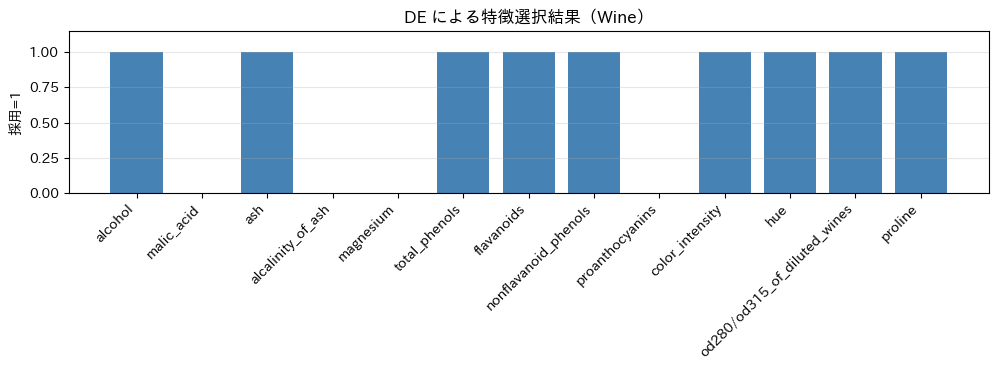

In [4]:
"""演習：DE で Wine + SVM の特徴選択を行う．"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import differential_evolution
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    plt.rcParams["font.family"] = "sans-serif"


def make_feature_selection_objective(
    X: np.ndarray,
    y: np.ndarray,
    n_splits: int = 5,
    alpha: float = 0.01,
):
    """連続ベクトルを二値マスクに変換する DE 用目的関数を返す．"""

    n_features = X.shape[1]

    def objective(z: np.ndarray) -> float:
        mask = np.asarray(z > 0.5, dtype=bool)
        selected_count = int(np.sum(mask))
        if selected_count == 0:
            return 1.5

        X_sel = X[:, mask]
        pipe = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
            ]
        )
        scores = cross_val_score(pipe, X_sel, y, cv=n_splits, scoring="accuracy")
        acc = float(np.mean(scores))
        sparsity_penalty = alpha * (selected_count / n_features)
        return 1.0 - acc + sparsity_penalty

    return objective


wine = load_wine()
X = np.asarray(wine.data, dtype=float)
y = np.asarray(wine.target, dtype=int)
feature_names = list(wine.feature_names)

obj = make_feature_selection_objective(X, y, n_splits=5, alpha=0.01)
bounds = [(0.0, 1.0)] * X.shape[1]

res = differential_evolution(
    obj,
    bounds=bounds,
    strategy="best1bin",
    maxiter=60,
    popsize=12,
    mutation=(0.5, 1.0),
    recombination=0.9,
    seed=23,
    polish=False,
)

best_z = np.asarray(res.x, dtype=float)
best_mask = best_z > 0.5
selected_names = [name for name, use in zip(feature_names, best_mask) if use]

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
    ]
)
baseline_acc = float(np.mean(cross_val_score(pipe, X, y, cv=5, scoring="accuracy")))
selected_acc = float(np.mean(cross_val_score(pipe, X[:, best_mask], y, cv=5, scoring="accuracy")))

print(f"ベースライン（全特徴）CV 精度: {baseline_acc:.4f}")
print(f"DE 選択特徴 CV 精度: {selected_acc:.4f}")
print(f"採用特徴数: {int(np.sum(best_mask))} / {X.shape[1]}")
print("採用特徴:", selected_names)

fig, ax = plt.subplots(figsize=(10, 3.8))
xpos = np.arange(len(feature_names))
ax.bar(xpos, best_mask.astype(int), color="steelblue")
ax.set_xticks(xpos)
ax.set_xticklabels(feature_names, rotation=45, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("採用=1")
ax.set_title("DE による特徴選択結果（Wine）")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


## 7. 確認問題

1. DE/rand/1/bin の `rand`，`1`，`bin` は何を意味するか．
2. $F$ を大きくしたとき，探索挙動はどう変わりやすいか．
3. $CR$ を小さくしすぎると，どんな問題が起こりうるか．
4. **典型 GA**（2 親交叉＋突然変異など）と DE で，変異・交叉・選択の役割はどう対応し，どこが異なるか．
5. 演習セルの `alpha` を増減したとき，採用特徴数と精度はどう変化したか．

---


### 参考リンク

- SciPy `differential_evolution`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.differential_evolution.html
- 差分進化の概要と Mutation／Crossover／Selection の整理（MyEnigma）: https://myenigma.hatenablog.com/entry/2022/02/12/225407
- DE の実装観点と用語対応（Qiita）: https://qiita.com/pocokhc/items/43e50c22f5ad5af5adde
- 差分進化によるハイパーパラメータ探索の動機（勾配不要・並列化），戦略名の読み方，二項交叉の幾何学的直感など（Qiita, n-suzuki）: https://qiita.com/n-suzuki/items/b8d4ccc4b6936120567e
- 第4回 PSO（速度モデルとの対比用）: https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso
- 第5回 ACO: https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture05-aco-tsp
